In [ ]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv"

df = pd.read_csv(url)

print(df.head())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St 

In [ ]:
print(df.dtypes)

print(df.isnull().sum())

print(df.describe())

for col in ["sex", "pclass", "embarked", "survived"]:
    print(col, ":", df[col].nunique())

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64
            pclass     survived          age        sibsp        parch  \
count  1309.000000  1309.000000  1046.000000  1309.000000  1309.000000   
mean      2.294882     0.381971    29.881135     0.498854     0.385027   
std       0.837836     0.486055    14.413500     1.041658     0.865560   
min       1.000000     0.000000     0.166700     0.000000     0.000000   
25%       2.000000     0.000000    21.000000     0.000000

In [ ]:
df["age"] = df["age"].fillna(df["age"].mean())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df = df.drop(columns=["cabin", "boat", "body"])

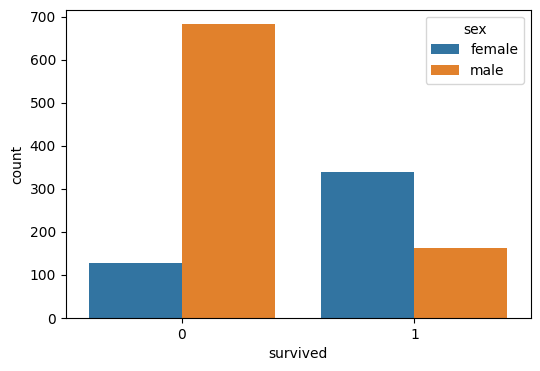

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="survived", hue="sex")

plt.show()

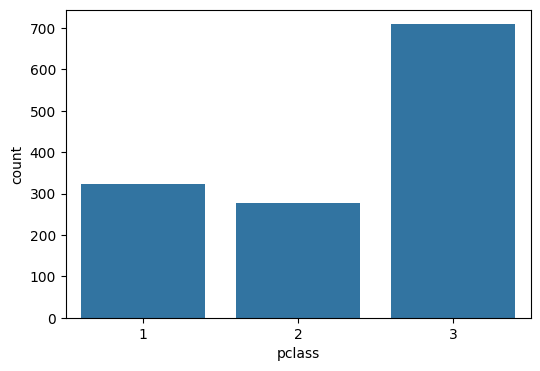

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="pclass")

plt.show()

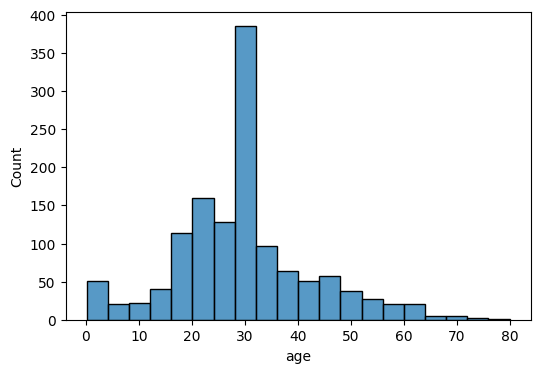

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(data=df, x="age", bins=20)

plt.show()

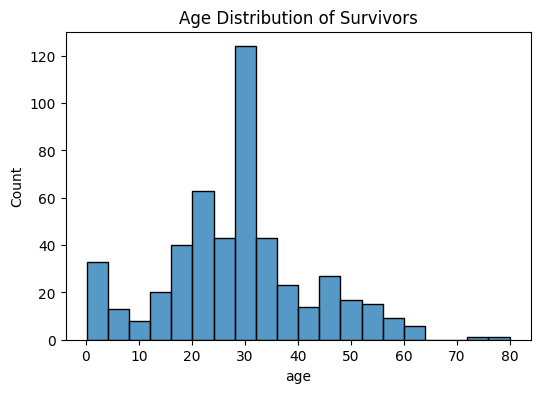

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df[df["survived"] == 1]["age"], bins=20)

plt.title("Age Distribution of Survivors")

plt.show()

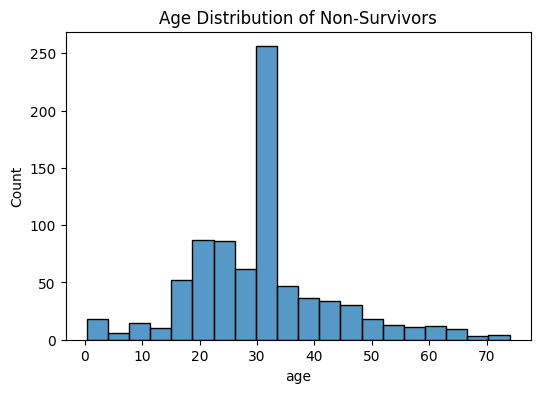

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df[df["survived"] == 0]["age"], bins=20)

plt.title("Age Distribution of Non-Survivors")

plt.show()

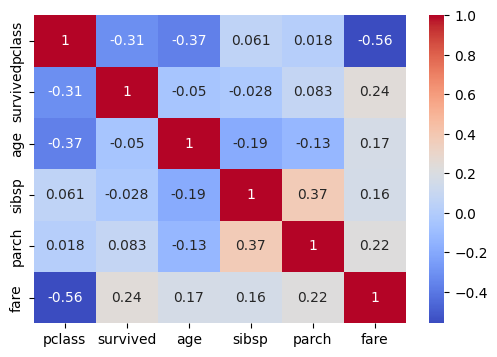

In [ ]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(6,4))

sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")

plt.show()